<a href="https://colab.research.google.com/github/christianjakegabrillo-a11y/Gabrillo_Acivity01/blob/main/Gabrillo_ml_activity_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
path =  kagglehub.dataset_download("larsen0966/student-performance-data-set")
print("path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
path to dataset files: /kaggle/input/student-performance-data-set


In [ ]:
print(os.listdir(path))

In [7]:
file_path=os.path.join(path,"student-por.csv")
df=pd.read_csv(file_path, sep= ",")

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

In [8]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print("Average final grade", df["G3"].mean())

In [9]:
print("Minimum final grade:", df["G3"].min())
print("Maximum final grade:", df["G3"].max())

Minimum final grade: 0
Maximum final grade: 19


In [ ]:
print(df["G3"].value_counts())

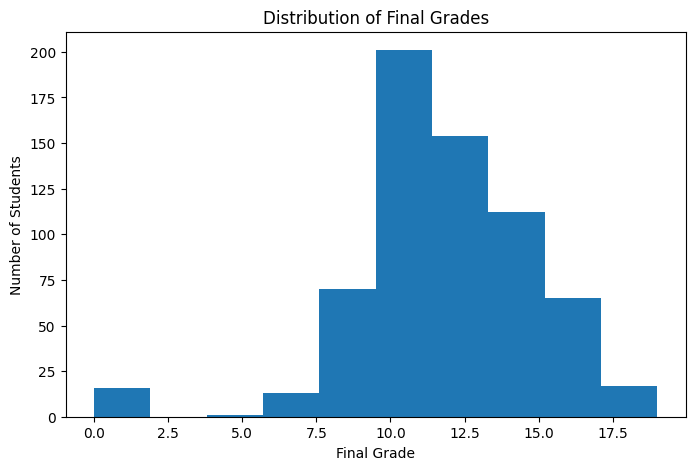

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

In [ ]:
df.groupby("sex")["G3"].mean()

In [ ]:
df.groupby("sex")["G3"].mean().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")
plt.show()

In [ ]:
df.groupby("studytime")["G3"].mean()

In [ ]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")
plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")
plt.show()

In [ ]:
print(df["absences"].corr(df["G3"]))

In [27]:
df["pass"] = (df["G3"]>=10).astype(int)

In [ ]:
print(df["pass"].value_counts())

In [28]:
features =[
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
]
x = df[features]
y = df["pass"]

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
model=DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [31]:
y_pred = model.predict(x_test)
print(y_pred)

[1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1
 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1]


In [32]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9153846153846154


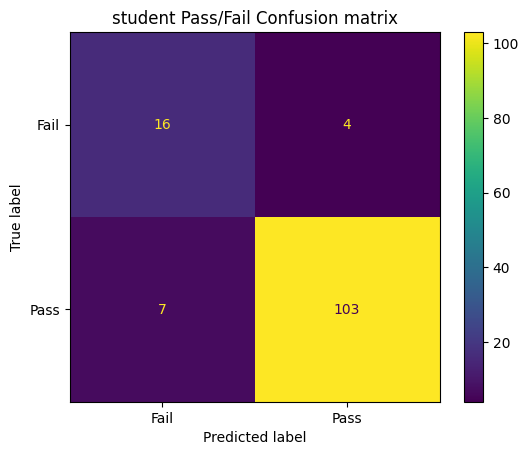

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels = ["Fail", "Pass"]
)
disp.plot()

plt.title("student Pass/Fail Confusion matrix")
plt.show()

In [34]:
result = x_test.copy()

result["Actual"] =y_test
result["Predicted"] = y_pred

result.head(10)

,age,studytime,failures,absences,G1,G2,Actual,Predicted
28,16,2,0,2,12,12,1,1
124,16,2,0,0,12,11,1,1
135,16,1,0,12,15,13,1,1
641,18,3,0,0,14,17,1,1
552,19,2,2,2,9,9,1,1
570,16,1,0,6,7,8,0,0
502,17,4,1,2,10,8,0,0
410,17,2,0,0,13,17,1,1
596,17,2,0,0,17,18,1,1
324,18,1,0,10,10,10,1,1


In [35]:
result["risk"] = result["Predicted"].map({
      0:"At Risk",
      1:"Likely to Pass "
})
result.head(10 )

,age,studytime,failures,absences,G1,G2,Actual,Predicted,risk
28,16,2,0,2,12,12,1,1,Likely to Pass
124,16,2,0,0,12,11,1,1,Likely to Pass
135,16,1,0,12,15,13,1,1,Likely to Pass
641,18,3,0,0,14,17,1,1,Likely to Pass
552,19,2,2,2,9,9,1,1,Likely to Pass
570,16,1,0,6,7,8,0,0,At Risk
502,17,4,1,2,10,8,0,0,At Risk
410,17,2,0,0,13,17,1,1,Likely to Pass
596,17,2,0,0,17,18,1,1,Likely to Pass
324,18,1,0,10,10,10,1,1,Likely to Pass


In [36]:
result["Risk"] = result["Predicted"].map({
    0: "Prioritize for academic intervention",
    1: "Continue regular monitoring"
})
result.head(10)

,age,studytime,failures,absences,G1,G2,Actual,Predicted,risk,Risk
28,16,2,0,2,12,12,1,1,Likely to Pass,Continue regular monitoring
124,16,2,0,0,12,11,1,1,Likely to Pass,Continue regular monitoring
135,16,1,0,12,15,13,1,1,Likely to Pass,Continue regular monitoring
641,18,3,0,0,14,17,1,1,Likely to Pass,Continue regular monitoring
552,19,2,2,2,9,9,1,1,Likely to Pass,Continue regular monitoring
570,16,1,0,6,7,8,0,0,At Risk,Prioritize for academic intervention
502,17,4,1,2,10,8,0,0,At Risk,Prioritize for academic intervention
410,17,2,0,0,13,17,1,1,Likely to Pass,Continue regular monitoring
596,17,2,0,0,17,18,1,1,Likely to Pass,Continue regular monitoring
324,18,1,0,10,10,10,1,1,Likely to Pass,Continue regular monitoring


In [38]:
probabilities = model.predict_proba(x_test)
result["Probability_of_falling"] = probabilities[:, 0]
result.sort_values(
    "Probability_of_falling",
    ascending=False,
    inplace=True
)
result.head(20)

,age,studytime,failures,absences,G1,G2,Actual,Predicted,risk,Risk,Probability_of_falling
487,18,3,2,6,7,9,1,0,At Risk,Prioritize for academic intervention,1.000000
578,17,2,1,4,8,9,1,0,At Risk,Prioritize for academic intervention,1.000000
450,16,2,0,2,15,15,1,1,Likely to Pass,Continue regular monitoring,1.000000
596,17,2,0,0,17,18,1,1,Likely to Pass,Continue regular monitoring,1.000000
557,17,2,3,2,7,9,1,0,At Risk,Prioritize for academic intervention,1.000000
324,18,1,0,10,10,10,1,1,Likely to Pass,Continue regular monitoring,1.000000
575,18,1,0,8,10,11,1,1,Likely to Pass,Continue regular monitoring,1.000000
33,15,2,0,0,13,12,1,1,Likely to Pass,Continue regular monitoring,1.000000
458,16,4,0,0,13,10,1,1,Likely to Pass,Continue regular monitoring,1.000000
312,18,4,0,10,16,16,1,1,Likely to Pass,Continue regular monitoring,1.000000
